In [1]:
import sys
import os

sys.path.append('/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit')
sys.path.append('/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron')
sys.path.append('/home/paule/open_mc_projects/MC-1D_DT')


from src.neutron_class import Neutron
from src.source_class import Source, _BatchSource
from src.geometry_classes import Geometry, Material
import src.geometry_classes as geom
import src.performance_classes as perf
import src.tally_classes as tally
import src.vectfit as vf
import src.export_simulation_v3 as xpsim
import src.export_print_csv as xpcsv
import src.reconr_v2 as reconr
import src.parallel as parallel

import openmc

openmc.config['cross_sections'] = "/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/cross_sections.xml"





['/home/paule/anaconda3/envs/vectfit39/lib/python39.zip', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/lib-dynload', '', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit', '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron', '/home/paule/open_mc_projects/MC-1D_DT', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit']


In [2]:
# One slab of U238 — simple test case


# ============================================================================
# Uranium atom density
# ============================================================================
# Uranium metal density ~ 19.1 g/cm³,
# N = rho * Na / A  (atoms/cm³)
rho_U   = 19.1               # g/cm³
NA      = 6.02214076e23      # atoms/mol

x_U235 = 0.00                # 0% enrichment
x_U238 = 1.0 - x_U235

M_U8   = 238.05078826        # g/mol
M_U5   = 235.0439299         # g/mol
N_total_U8 = rho_U * NA / (x_U238 * M_U8 + x_U235 * M_U5)
N_total_U5 = rho_U * NA / (x_U235 * M_U5 + x_U238 * M_U8)

N_U235 = 1.0 * N_total_U5   # 0%  enrichment
N_U238 = 1.0 * N_total_U8   # 100%

slab1 = Material(
    name     = "cell 1",
    nuclides = [('U238', N_U238)],
    T        = 293.6,    # K (~20 °C)
)

slab2 = Material(
    name     = "cell 2",
    nuclides = [('U238', N_U238)],
    T        = 2000,     # K
)


[Material] Processing nuclide pair: U238 (Density: 4.83e+22)
[Material] Processing nuclide pair: U238 (Density: 4.83e+22)


In [3]:



# ============================================================================
# Geometry  (two slabs)
# ============================================================================
geom = Geometry(majorant_log=True, poll_interval=0.001, verbose=False)
geom.xs_dir = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/wmp'

geom.add_material(slab1)
geom.add_material(slab2)
geom.boundaries     = [0.0, 2.0, 15.0]  # cm
geom.material_array = [slab1, slab2]

# Flux tally: 5 energy groups
energy_bins = [10.0, 50.0, 600.0, 1e4, 1e6, 2e7]  # eV
geom.attach_flux_tally(energy_bins)

# Verification tally: same energy bins, surface at slab1/slab2 interface
geom.attach_verification_tally(
    energy_bins = energy_bins,
    surface_xs  = [0.0, 2.0, 15.0],        # slab1/slab2 interface
)

# Majorant and XS method
geom.maj_mat_method = "simple"  # majorant method: "maj_mat" 
geom.set_maj_xs_method(method="discrete", T_array=[0, 293, 500, 1000, 1500, 1900, 2000], xs_maj_file_dir='src/vectfit_data')  # majorant XS method: "vectfit" 
geom.set_access_method("reconr", last_energy= 600, err_lim=0.0001, err_max=0.001)  # access method: "fly" or "simple"
geom.set_mode("analysis", filename='validation/xs_generation/statepoint.200.h5')


# ============================================================================
# Source  (monoenergetic, at x=0, pointing right)
# ============================================================================
N_NEUTRONS  = 20000  # neutrons per batch
N_BATCHES   = 10    # number of independent batches (100 neutrons each)

src = Source(
    neutron_nbr  = N_NEUTRONS,
    energy_range = [500, 150],
    energy_dist  = "mono",
    position     = [0.0, 0.0, 0.0],
    direction    = [1.0, 0.0, 0.0],
)





 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
15.0

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)
[Setup] Building majorant XS grid for RECONR access method...
4309
600
 Evaluating the majorant cross section with RECONR stacking algorithm
err_lim = 0.0001, err_max = 0.001, err_int = 5e-09
last energy to add = 599.5985648781146 eV
number of windows = 4309
done
Second pass done — 17980 points
No inversions found in energy grid before dedup
Deduplication removed 0 points
Building O(1) Window Pointers...
Window pointer table: 747 windows
Final grid size:      17980 points
Window Pointers: [0, 108, 152, 175, 189, 199, 207, 213, 217, 221, 225, 228, 230, 232, 234, 236, 238, 240, 241, 242, 243, 244, 255, 256, 257, 258, 259, 260, 261, 

206.331904
18.1273881


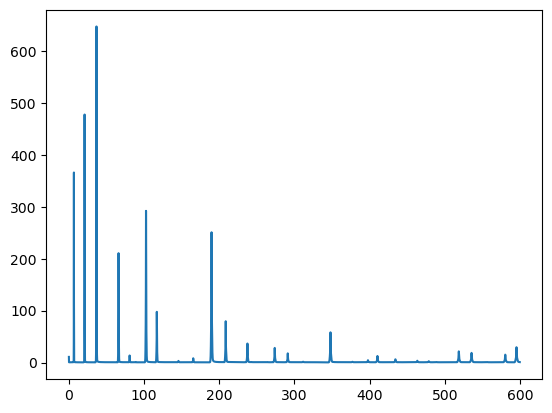

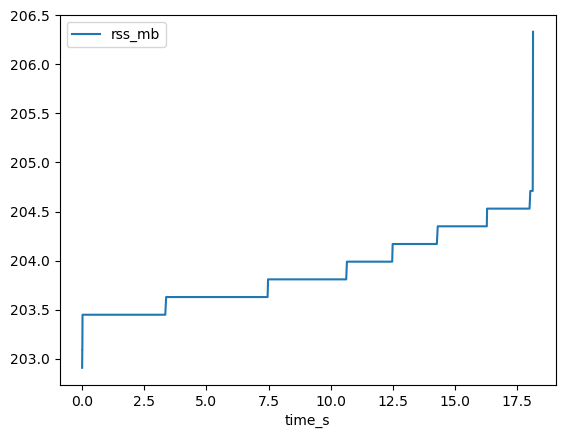

In [4]:
import matplotlib.pyplot as plt
if geom.access_method == "reconr":
    plt.plot(geom.reconr_e_grid, geom.reconr_maj_xs_grid)
a = geom.memory_summary()

df_poll = geom.memory.poll_to_dataframe()
df_poll.plot(x="time_s", y="rss_mb")

print(max(df_poll["rss_mb"]))
print(df_poll[df_poll["rss_mb"] == max(df_poll["rss_mb"])]["time_s"].values[0])

In [5]:
batch_stats = geom.run_source( src)
print(f"mode: {geom.mode}")
print(f"majorant XS method: {geom.maj_xs_method}")
print(f"majorant material method: {geom.maj_mat_method}")
print(f"access method: {geom.access_method}")
print(geom.summary())

#xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= False, save_csv= True, output_dir=f'cross_batch_stats_{geom.maj_xs_method}_{geom.maj_mat_method}_reconr_v2_new.csv')




 [Memory] Tracker started (poll interval: 1 ms)

[Simulation] Running source (Mode: analysis)

 [Memory] Tracker stopped.
mode: analysis
majorant XS method: discrete
majorant material method: simple
access method: reconr
  SIMULATION SUMMARY
  Neutrons simulated      :     20,000
  Absorbed fraction       :    46.870%
  Leaked fraction         :    53.130%
------------------------------------------------------------
  Mean scatters/neutron   :       7.12
  Mean virtual/neutron    :       0.25
  Mean path length  [cm]  :    13.2000
------------------------------------------------------------
  MAJORANT XS DIAGNOSTICS
  Majorant updates        :    162,383
  Mean majorant [cm⁻¹]    :     0.6925
  Max  majorant [cm⁻¹]    :    77.2257
  Mean margin (maj/real)  :      1.001
  Min margin (maj/real)  :      1.000
  Max margin (maj/real)  :      1.002
  Most-limiting material  : cell 2
  Wrong majorant updates  :          0
  Wrong majorant mean error sum : 0.0000
  Wrong majorant rate     : 

In [6]:
xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= True)


  CROSS-BATCH STATISTICS

  FLUX TALLY [cm · src-n⁻¹]
  Group                               Mean           ±Std    Rel.Err
  -----------------------------------------------------------------
  10-50 eV                      0.0000e+00     0.0000e+00        inf
  50-600 eV                     1.3402e+01     1.4682e-01     0.0110
  600-10000 eV                  0.0000e+00     0.0000e+00        inf
  10000-1000000 eV              0.0000e+00     0.0000e+00        inf
  1000000-20000000 eV           0.0000e+00     0.0000e+00        inf

  ABSORPTION RATE [reactions · src-n⁻¹]
  Region / Group                      Mean           ±Std    Rel.Err
  -----------------------------------------------------------------
  0.0-2.0 cm | 10-50 eV         0.0000e+00     0.0000e+00        inf
  0.0-2.0 cm | 50-600 eV        9.1200e-02     3.5988e-03     0.0395
  0.0-2.0 cm | 600-10000 eV     0.0000e+00     0.0000e+00        inf
  0.0-2.0 cm | 10000-1000000 eV     0.0000e+00     0.0000e+00        inf
  0.0

  MEMORY TRACKER SUMMARY
  Baseline RSS          : 2.107e+02 MB
  Peak RSS (continuous) : 2.256e+02 MB
  Total growth          : +1.491e+01 MB
-----------------------------------------------------------------
  Label                         RSS (MB)  Delta (MB)  Time (s)
-----------------------------------------------------------------
  init                             210.7        +0.0     0.002
  add_material_cell 1              210.7        +0.0     0.003
  stop                             210.7        +0.0     0.003
  init                             210.7        +0.0     0.004
  add_material_cell 2              210.7        +0.0     0.004
  stop                             210.7        +0.0     0.006
  init                             210.7        +0.0     0.007
  maj_mat_method_setup             210.7        +0.0     0.007
  stop                             210.7        +0.0     0.008
  init                             210.7        +0.0     0.009
  maj_xs_method_setup           

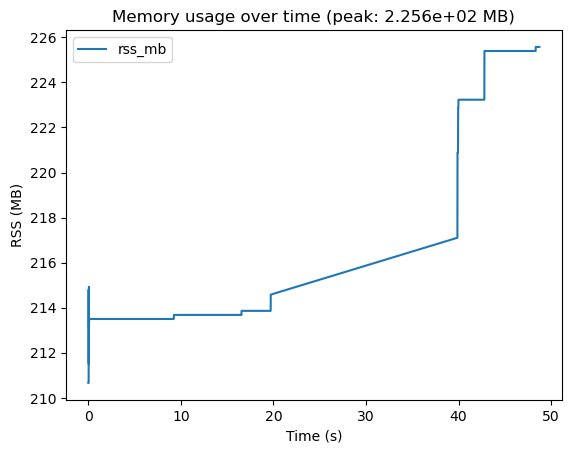

In [11]:
print(geom.memory_summary())
df_poll_2 = geom.memory.poll_to_dataframe()
figure, ax = plt.subplots()
df_poll_2.plot(x="time_s", y="rss_mb", ax=ax)
ax.set_title(f"Memory usage over time (peak: {max(df_poll_2['rss_mb']):.3e} MB)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("RSS (MB)")
print(df_poll_2.head())
print(max(df_poll_2["rss_mb"]))
print(df_poll_2[df_poll_2["rss_mb"] == max(df_poll_2["rss_mb"])]["time_s"].values[0])

In [12]:
#xpsim.export_simulation(geom, batch_stats, print_to_console=False, save_csv=True, output_dir=f'simulation_output_{geom.maj_xs_method}_{geom.maj_mat_method}_{geom.access_method}.csv')
xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= False, save_csv= True, output_dir=f'cross_batch_stats_{geom.maj_xs_method}_{geom.maj_mat_method}_{geom.access_method}.csv')


Cross-batch statistics saved → cross_batch_stats_vectfit_simple_reconr.csv
